In [2]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('india_air_quality_consolidated.csv')

In [8]:
df.head()

,city,location,date,pm25,pm10,o3,no2,so2,co
0,Delhi,Anand Vihar,2025/12/1,260,362,335,39,51,15
1,Delhi,Anand Vihar,2025/12/2,327,198,11,32,18,5
2,Delhi,Anand Vihar,2025/12/3,236,194,7,26,8,17
3,Delhi,Anand Vihar,2025/12/4,224,225,7,35,11,15
4,Delhi,Anand Vihar,2025/12/5,270,,,,,


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96755 entries, 0 to 96754
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   city      96755 non-null  str  
 1   location  96755 non-null  str  
 2   date      96755 non-null  str  
 3   pm25      96755 non-null  str  
 4   pm10      96755 non-null  str  
 5   o3        96755 non-null  str  
 6   no2       96755 non-null  str  
 7   so2       90132 non-null  str  
 8   co        96755 non-null  str  
dtypes: str(9)
memory usage: 10.7 MB


In [10]:
# 1. Convert the date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. List all pollutant columns
pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

# 3. Strip whitespace and convert strings to float (invalid entries become NaN)
for col in pollutant_cols:
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        df[col] = df[col].astype(str).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Check the updated types and missing value counts
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

city                   str
location               str
date        datetime64[us]
pm25               float64
pm10               float64
o3                 float64
no2                float64
so2                float64
co                 float64
dtype: object

Missing values per column:
city            0
location        0
date            0
pm25         3410
pm10        15544
o3           6181
no2          6371
so2         16157
co           7769
dtype: int64


In [11]:
# 1. Sort chronologically by location and date
df = df.sort_values(by=['city', 'location', 'date']).reset_index(drop=True)

# 2. Forward-fill and backward-fill within each specific location
# This bridges short sensor outages using readings from the same monitoring station
pollutants = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
df[pollutants] = df.groupby(['city', 'location'])[pollutants].transform(
    lambda group: group.ffill().bfill()
)

# 3. Drop rows where target pm25 is still NaN (stations where pm25 was never measured)
df_clean = df.dropna(subset=['pm25']).copy()

# 4. Check remaining missing values and final row count
print("Remaining missing values:")
print(df_clean.isnull().sum())
print(f"\nFinal dataset shape: {df_clean.shape}")

Remaining missing values:
city           0
location       0
date           0
pm25           0
pm10           0
o3             0
no2            0
so2         6623
co             0
dtype: int64

Final dataset shape: (96755, 9)


In [12]:
# 1. Fill remaining SO2 using city-level median, then fallback to global median
df_clean['so2'] = df_clean.groupby('city')['so2'].transform(lambda x: x.fillna(x.median()))
df_clean['so2'] = df_clean['so2'].fillna(df_clean['so2'].median())

# 2. Extract useful time-based features from the date
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)

# 3. Create a 1-day lag feature for PM2.5 (yesterday's PM2.5 to predict today's)
df_clean['pm25_lag1'] = df_clean.groupby(['city', 'location'])['pm25'].shift(1)

# Backfill the single first row per station created by shifting
df_clean['pm25_lag1'] = df_clean.groupby(['city', 'location'])['pm25_lag1'].bfill()

# 4. Final null check
print("Remaining null values across all columns:")
print(df_clean.isnull().sum())
print(f"\nFinal clean shape: {df_clean.shape}")
df_clean.head(3)

Remaining null values across all columns:
city           0
location       0
date           0
pm25           0
pm10           0
o3             0
no2            0
so2            0
co             0
year           0
month          0
day            0
day_of_week    0
is_weekend     0
pm25_lag1      0
dtype: int64

Final clean shape: (96755, 15)


,city,location,date,pm25,pm10,o3,no2,so2,co,year,month,day,day_of_week,is_weekend,pm25_lag1
0,Alwar,Moti Doongri,2018-01-20,165.0,94.0,41.0,20.0,6.0,12.0,2018,1,20,5,1,165.0
1,Alwar,Moti Doongri,2018-01-21,165.0,94.0,37.0,21.0,7.0,11.0,2018,1,21,6,1,165.0
2,Alwar,Moti Doongri,2018-01-22,181.0,94.0,22.0,20.0,6.0,11.0,2018,1,22,0,0,165.0


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



In [14]:
# 1. Define Features (X) and Target (y)
features = ['pm10', 'o3', 'no2', 'so2', 'co', 'month', 'is_weekend', 'pm25_lag1']
target = 'pm25'

X = df_clean[features]
y = df_clean[target]

# 2. Time-aware split: sort chronologically so we don't leak future data into the past
# 80% train, 20% test
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Train Multiple Linear Regression Baseline
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 4. Predict on Test Set
y_pred = model_lr.predict(X_test)

# 5. Evaluate Baseline Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Baseline Multiple Linear Regression Results ---")
print(f"R-squared (R2 Score) : {r2:.4f}")
print(f"Mean Absolute Error   : {mae:.2f} µg/m³")
print(f"Root Mean Squared Err : {rmse:.2f} µg/m³\n")

# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model_lr.coef_})
print("Feature Coefficients:")
print(coef_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))

--- Baseline Multiple Linear Regression Results ---
R-squared (R2 Score) : 0.7274
Mean Absolute Error   : 24.89 µg/m³
Root Mean Squared Err : 43.36 µg/m³

Feature Coefficients:
   Feature  Coefficient
 pm25_lag1     0.731683
        co     0.323617
       no2     0.228729
     month     0.162035
      pm10     0.144847
        o3     0.004236
       so2    -0.015929
is_weekend    -0.601576


In [15]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model
model_rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

# 2. Train the model
model_rf.fit(X_train, y_train)

# 3. Predict on Test Set
y_pred_rf = model_rf.predict(X_test)

# 4. Evaluate Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Results ---")
print(f"R-squared (R2 Score) : {r2_rf:.4f}")
print(f"Mean Absolute Error   : {mae_rf:.2f} µg/m³")
print(f"Root Mean Squared Err : {rmse_rf:.2f} µg/m³\n")

# 5. Feature Importance
importances = model_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
print("Feature Importance Ranking:")
print(
    feat_imp_df.sort_values(by='Importance', ascending=False).to_string(
        index=False
    )
)

--- Random Forest Regressor Results ---
R-squared (R2 Score) : 0.7131
Mean Absolute Error   : 23.05 µg/m³
Root Mean Squared Err : 44.48 µg/m³

Feature Importance Ranking:
   Feature  Importance
 pm25_lag1    0.894043
      pm10    0.057701
        co    0.012306
     month    0.010845
       no2    0.009757
        o3    0.008108
       so2    0.006435
is_weekend    0.000804


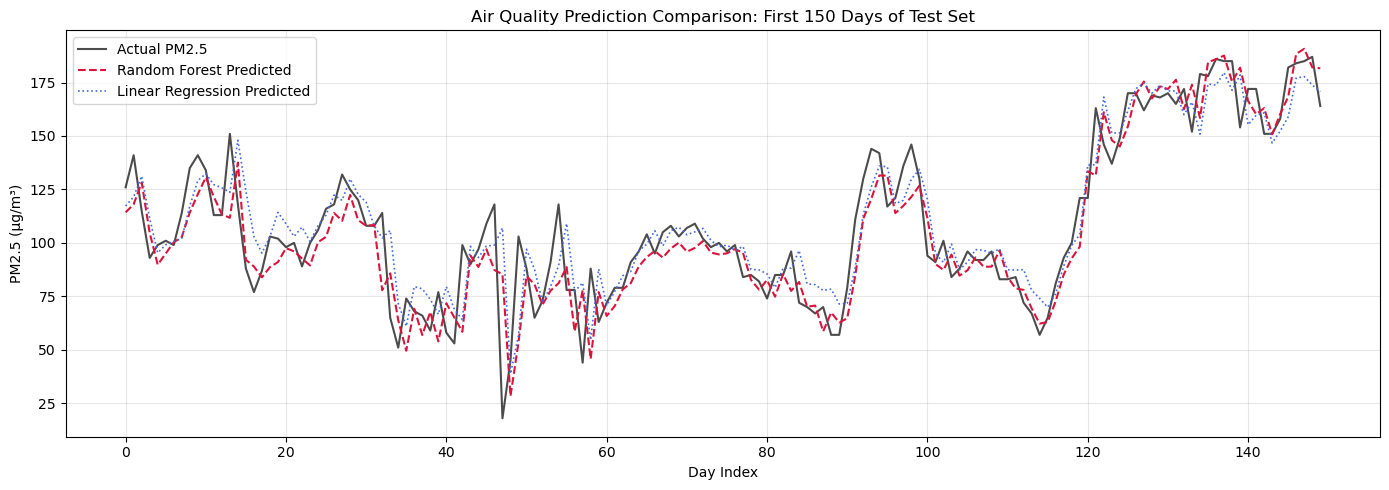

In [16]:
import matplotlib.pyplot as plt

# Take the first 150 days of the test set for clean visualization
plt.figure(figsize=(14, 5))
plt.plot(
    y_test.values[:150], label='Actual PM2.5', color='black', alpha=0.7, lw=1.5
)
plt.plot(
    y_pred_rf[:150],
    label='Random Forest Predicted',
    color='crimson',
    linestyle='--',
    lw=1.5,
)
plt.plot(
    y_pred[:150],
    label='Linear Regression Predicted',
    color='royalblue',
    linestyle=':',
    lw=1.2,
)

plt.title('Air Quality Prediction Comparison: First 150 Days of Test Set')
plt.xlabel('Day Index')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
import joblib

# Save the trained Random Forest model
joblib.dump(model_rf, 'random_forest_aqi_model.pkl')
print("Model saved successfully as 'random_forest_aqi_model.pkl'")

Model saved successfully as 'random_forest_aqi_model.pkl'
